In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('cwd:', Path.cwd())

cwd: d:\Kuliah\Semester 8\Skripsi\Kode


In [9]:
# ── Konfigurasi lokasi file hasil (LOKAL) ─────────────────────────────────────
# Jalankan notebook ini dari folder yang sama dengan file hasil:
#   vectors_fold_01.npz, vectors_fold_02.npz, dst.
#
# Default: folder kerja saat ini (biasanya folder notebook di lokal).
# Jika file hasil ada di folder lain, ubah OUT_DIR ke path Windows:
#   OUT_DIR = Path(r"D:\\Kuliah\\Semester 8\\Skripsi\\Kode")

OUT_DIR = Path.cwd()  # ganti jika perlu

PATTERNS = [
    "vectors_fold_*.npz",
    "nomask_vectors_fold_*.npz",
]

print("OUT_DIR:", OUT_DIR.resolve())

OUT_DIR: D:\Kuliah\Semester 8\Skripsi\Kode


In [10]:
# ── Temukan semua file .npz ───────────────────────────────────────────────────

npz_files = []
for pat in PATTERNS:
    npz_files.extend([str(p) for p in OUT_DIR.glob(pat)])

npz_files = sorted(set(npz_files))
print(f"Ditemukan {len(npz_files)} file .npz")
for f in npz_files[:20]:
    print(" -", f)
if len(npz_files) > 20:
    print("... (dipotong)")

assert len(npz_files) > 0, (
    "Tidak ada file .npz ditemukan. Pastikan OUT_DIR benar dan file hasil sudah ada, "
    "misalnya vectors_fold_01.npz dst."
)

Ditemukan 12 file .npz
 - d:\Kuliah\Semester 8\Skripsi\Kode\nomask_vectors_fold_01.npz
 - d:\Kuliah\Semester 8\Skripsi\Kode\nomask_vectors_fold_02.npz
 - d:\Kuliah\Semester 8\Skripsi\Kode\nomask_vectors_fold_03.npz
 - d:\Kuliah\Semester 8\Skripsi\Kode\nomask_vectors_fold_04.npz
 - d:\Kuliah\Semester 8\Skripsi\Kode\nomask_vectors_fold_05.npz
 - d:\Kuliah\Semester 8\Skripsi\Kode\nomask_vectors_fold_06.npz
 - d:\Kuliah\Semester 8\Skripsi\Kode\nomask_vectors_fold_07.npz
 - d:\Kuliah\Semester 8\Skripsi\Kode\nomask_vectors_fold_08.npz
 - d:\Kuliah\Semester 8\Skripsi\Kode\nomask_vectors_fold_09.npz
 - d:\Kuliah\Semester 8\Skripsi\Kode\nomask_vectors_fold_10.npz
 - d:\Kuliah\Semester 8\Skripsi\Kode\nomask_vectors_fold_11.npz
 - d:\Kuliah\Semester 8\Skripsi\Kode\nomask_vectors_fold_12.npz


In [11]:
# ── Load & ringkasan per file ─────────────────────────────────────────────────
# Catatan penting:
# - File `vectors_fold_*.npz` dari `siamese_bilstm.ipynb` berisi *vektor encoder* + y.
# - MAE model regresi hanya bisa dihitung jika file juga menyimpan `y_pred`.


def _safe_item(x):
    # np.array([1]) -> 1
    if isinstance(x, np.ndarray) and x.shape == (1,):
        return x.item()
    return x


def mae(a, b):
    a = np.asarray(a).astype(np.float32)
    b = np.asarray(b).astype(np.float32)
    return float(np.mean(np.abs(a - b)))


def rmse(a, b):
    a = np.asarray(a).astype(np.float32)
    b = np.asarray(b).astype(np.float32)
    return float(np.sqrt(np.mean((a - b) ** 2)))


rows = []

for path in npz_files:
    p = Path(path)
    z = np.load(path, allow_pickle=True)
    keys = set(z.files)

    required = {
        "eq_train","eak_train","ea_train","y_train",
        "eq_val","eak_val","ea_val","y_val",
        "eq_test","eak_test","ea_test","y_test",
    }
    missing = required - keys
    if missing:
        print(f"[SKIP] {p.name} missing keys: {sorted(missing)}")
        continue

    test_idpsj = _safe_item(z["test_idpsj"]) if "test_idpsj" in keys else None
    val_idpsj  = _safe_item(z["val_idpsj"])  if "val_idpsj"  in keys else None

    y_test = z["y_test"].astype(np.float32)

    has_pred = "y_pred" in keys
    mae_cont = None
    rmse_cont = None
    mae_round = None
    rmse_round = None

    if has_pred:
        y_pred_raw = z["y_pred"].astype(np.float32).reshape(-1)
        y_true = y_test.reshape(-1)
        mae_cont = mae(y_true, y_pred_raw)
        rmse_cont = rmse(y_true, y_pred_raw)

        # versi dibulatkan ke 1..10 (mirip notebook direct)
        y_pred_round = np.clip(np.round(y_pred_raw), 1, 10)
        mae_round = mae(y_true, y_pred_round)
        rmse_round = rmse(y_true, y_pred_round)

    rows.append({
        "file": p.name,
        "kind": "nomask" if "nomask" in p.name else "mask",
        "test_idpsj": test_idpsj,
        "val_idpsj": val_idpsj,
        "n_train": int(len(z["y_train"])),
        "n_val": int(len(z["y_val"])),
        "n_test": int(len(y_test)),
        "enc_dim": int(z["ea_train"].shape[-1]),
        "has_y_pred": bool(has_pred),
        "MAE(cont)": mae_cont,
        "RMSE(cont)": rmse_cont,
        "MAE(round)": mae_round,
        "RMSE(round)": rmse_round,
        "eq_shape": tuple(z["eq_train"].shape),
        "eak_shape": tuple(z["eak_train"].shape),
        "ea_shape": tuple(z["ea_train"].shape),
        "y_test_min": float(np.min(y_test)) if len(y_test) else None,
        "y_test_max": float(np.max(y_test)) if len(y_test) else None,
    })

summary = pd.DataFrame(rows)
print("Ringkasan file:")
display(summary)

if not summary["has_y_pred"].any():
    print(
        "\nTidak ada kolom `y_pred` di file .npz, jadi MAE belum bisa dihitung dari hasil ini. "
        "Kalau Anda ingin, saya bisa ubah notebook training agar menyimpan `y_pred` (dan MAE/RMSE) per fold."
    )

Ringkasan file:


,file,kind,test_idpsj,val_idpsj,n_train,n_val,n_test,enc_dim,has_y_pred,MAE(cont),RMSE(cont),MAE(round),RMSE(round),eq_shape,eak_shape,ea_shape,y_test_min,y_test_max
0,nomask_vectors_fold_01.npz,nomask,1,2,1440,89,214,256,False,None,None,None,None,"(1440, 256)","(1440, 256)","(1440, 256)",1.0,10.0
1,nomask_vectors_fold_02.npz,nomask,2,3,1596,58,89,256,False,None,None,None,None,"(1596, 256)","(1596, 256)","(1596, 256)",1.0,10.0
2,nomask_vectors_fold_03.npz,nomask,3,4,1620,65,58,256,False,None,None,None,None,"(1620, 256)","(1620, 256)","(1620, 256)",1.0,10.0
3,nomask_vectors_fold_04.npz,nomask,4,5,1580,98,65,256,False,None,None,None,None,"(1580, 256)","(1580, 256)","(1580, 256)",1.0,10.0
4,nomask_vectors_fold_05.npz,nomask,5,6,1524,121,98,256,False,None,None,None,None,"(1524, 256)","(1524, 256)","(1524, 256)",1.0,10.0
5,nomask_vectors_fold_06.npz,nomask,6,7,1545,77,121,256,False,None,None,None,None,"(1545, 256)","(1545, 256)","(1545, 256)",1.0,10.0
6,nomask_vectors_fold_07.npz,nomask,7,8,1370,296,77,256,False,None,None,None,None,"(1370, 256)","(1370, 256)","(1370, 256)",1.0,10.0
7,nomask_vectors_fold_08.npz,nomask,8,9,1184,263,296,256,False,None,None,None,None,"(1184, 256)","(1184, 256)","(1184, 256)",1.0,10.0
8,nomask_vectors_fold_09.npz,nomask,9,10,1327,153,263,256,False,None,None,None,None,"(1327, 256)","(1327, 256)","(1327, 256)",1.0,10.0
9,nomask_vectors_fold_10.npz,nomask,10,11,1358,232,153,256,False,None,None,None,None,"(1358, 256)","(1358, 256)","(1358, 256)",1.0,10.0



Tidak ada kolom `y_pred` di file .npz, jadi MAE belum bisa dihitung dari hasil ini. Kalau Anda ingin, saya bisa ubah notebook training agar menyimpan `y_pred` (dan MAE/RMSE) per fold.


In [12]:
# ── Simpan ringkasan ke CSV ───────────────────────────────────────────────────
OUT_CSV = OUT_DIR / "vectors_folds_summary.csv"
summary.to_csv(OUT_CSV, index=False)
print("Saved ->", OUT_CSV.resolve())

Saved -> D:\Kuliah\Semester 8\Skripsi\Kode\vectors_folds_summary.csv


File: nomask_vectors_fold_01.npz
Keys: ['eq_train', 'eak_train', 'ea_train', 'y_train', 'eq_val', 'eak_val', 'ea_val', 'y_val', 'eq_test', 'eak_test', 'ea_test', 'y_test', 'test_idpsj', 'val_idpsj']
Shapes:
  eq_test : (214, 256)
  eak_test: (214, 256)
  ea_test : (214, 256)
  y_test  : (214,)


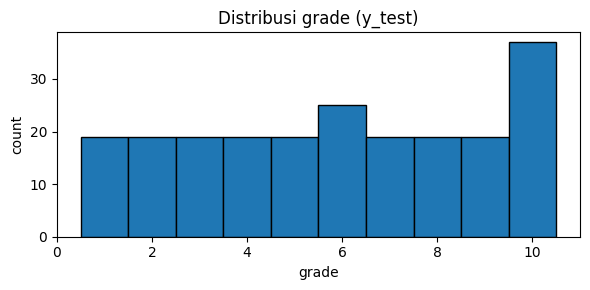

In [13]:
# ── Contoh: buka 1 fold dan lihat distribusi grade test ───────────────────────
example_path = Path(npz_files[0])
z = np.load(str(example_path), allow_pickle=True)

print("File:", example_path.name)
print("Keys:", z.files)
print("Shapes:")
print("  eq_test :", z["eq_test"].shape)
print("  eak_test:", z["eak_test"].shape)
print("  ea_test :", z["ea_test"].shape)
print("  y_test  :", z["y_test"].shape)

y_test = z["y_test"].astype(int)
plt.figure(figsize=(6, 3))
plt.hist(y_test, bins=np.arange(y_test.min(), y_test.max() + 2) - 0.5, edgecolor='black')
plt.title("Distribusi grade (y_test)")
plt.xlabel("grade")
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [7]:
# ── (Opsional) Gabungkan semua split test dari semua fold ─────────────────────
# Berguna untuk analisis downstream (mis. KNN/FAISS/regresi) tanpa training ulang.

all_folds = []
for path in npz_files:
    p = Path(path)
    z = np.load(path, allow_pickle=True)
    if not all(k in z.files for k in ["eq_test", "eak_test", "ea_test", "y_test"]):
        continue
    all_folds.append({
        "file": p.name,
        "eq": z["eq_test"].astype(np.float32),
        "eak": z["eak_test"].astype(np.float32),
        "ea": z["ea_test"].astype(np.float32),
        "y": z["y_test"].astype(np.float32),
    })

if len(all_folds) == 0:
    print("Tidak ada test split yang bisa digabung.")
else:
    eq  = np.concatenate([d["eq"]  for d in all_folds], axis=0)
    eak = np.concatenate([d["eak"] for d in all_folds], axis=0)
    ea  = np.concatenate([d["ea"]  for d in all_folds], axis=0)
    y   = np.concatenate([d["y"]   for d in all_folds], axis=0)

    out_npz = OUT_DIR / "all_folds_test_vectors.npz"
    np.savez(out_npz, eq=eq, eak=eak, ea=ea, y=y)

    print("Gabungan test vectors:")
    print("  eq :", eq.shape)
    print("  eak:", eak.shape)
    print("  ea :", ea.shape)
    print("  y  :", y.shape)
    print("Saved ->", out_npz.resolve())

Gabungan test vectors:
  eq : (1743, 256)
  eak: (1743, 256)
  ea : (1743, 256)
  y  : (1743,)
Saved -> D:\Kuliah\Semester 8\Skripsi\Kode\all_folds_test_vectors.npz


In [ ]:
# ── Ambil MAE/RMSE dari `lopo_results.csv` (jika tersedia) ─────────────────
# Karena `vectors_fold_*.npz` dari `siamese_bilstm.ipynb` tidak menyimpan `y_pred`,
# cara paling langsung untuk dapat MAE/RMSE adalah membaca file hasil direct:
#   lopo_results.csv (berisi kolom: RMSE, MAE, test_idpsj, dst.)

search_root = Path.cwd()  # lokal saja

lopo_csvs = sorted(search_root.rglob("lopo_results.csv"),
                   key=lambda p: p.stat().st_mtime)

if len(lopo_csvs) == 0:
    print("Tidak menemukan `lopo_results.csv`. MAE/RMSE tidak bisa dihitung dari npz (karena tidak ada `y_pred`).")
else:
    # Pakai file terbaru
    lopo_csv = lopo_csvs[-1]
    print("Pakai:", lopo_csv)

    lopo = pd.read_csv(lopo_csv)

    required_cols = {"fold","test_idpsj","RMSE","MAE"}
    missing_cols = required_cols - set(lopo.columns)
    if missing_cols:
        raise ValueError(f"Kolom yang dibutuhkan tidak ada: {missing_cols}")

    print("\nRingkasan MAE/RMSE (dari CSV)")
    print(lopo[["fold","test_idpsj","RMSE","MAE"]].head(20).to_string(index=False))
    print(f"\nRata-rata RMSE: {lopo['RMSE'].mean():.4f} ± {lopo['RMSE'].std():.4f}")
    print(f"Rata-rata MAE : {lopo['MAE'].mean():.4f} ± {lopo['MAE'].std():.4f}")

    # Plot RMSE & MAE per fold (sama gaya dengan siamese_bilstm_direct.ipynb)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["RMSE", "MAE"]):
        ax.bar(lopo['test_idpsj'].astype(str), lopo[metric], color='steelblue', edgecolor='black')
        ax.axhline(lopo[metric].mean(), color='red', linestyle='--', label=f"Mean {metric}")
        ax.set_title(f"{metric} per Fold (test IDPSJ)")
        ax.set_xlabel('Test IDPSJ')
        ax.set_ylabel(metric)
        ax.legend()

    plt.tight_layout()

    out_plot = (search_root / "lopo_metrics_from_csv.png")
    plt.savefig(out_plot, dpi=150)
    plt.show()
    print("Saved ->", out_plot)

    # Tampilkan scatter yang sudah tersedia (jika ada)
    scatter_path = lopo_csv.parent / "scatter_all_folds.png"
    if scatter_path.exists():
        from PIL import Image
        img = Image.open(scatter_path)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title("scatter_all_folds.png")
        plt.show()
    else:
        print("scatter_all_folds.png tidak ditemukan di folder yang sama dengan lopo_results.csv.")